# SZ3 + model  vs  SPERR — PSNR vs Compression Ratio

Compare our **SZ3 + neural-residual** pipeline against **SPERR** (a wavelet compressor) across four datasets, one figure per dataset:

| Dataset | Target field(s) | Model params | Aux input |
|---|---|---|---|
| NYX 512³ | baryon density, temperature, dark matter density | 30k | other NYX fields |
| Miranda 1024³ | single field | 240k | — |
| Hurricane 100×500×500 | CLOUD | 6k | PRECIP,P,TC,U,V,W |
| Magnetic 512³ | single field | 30k | — |

Each curve sweeps the error bound to span a range of CR.  **SZ3 + model** stores the target's SZ3 stream + the model (bf16); **aux fields are raw side-info, not charged to CR** (NYX/Hurricane convention).  **SPERR** is standalone (its own bitstream) matched to each SZ3 point's PSNR (compare CR at equal quality); its PSNR is recomputed from the decompressed volume with the same formula.

In [1]:
import os, sys, time, subprocess
import numpy as np
import matplotlib.pyplot as plt
import torch

SPERR_BIN    = "/home/sam/Halo_Finder/SPERR/build/bin/sperr3d"
SZ3_LIB      = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
PYSZ_PATH    = "/home/sam/Data_Compression/SZ3/tools/pysz"
SCRIPTS_PATH = "/home/sam/Halo_Finder/Final_design/base_script"
for p in (PYSZ_PATH, SCRIPTS_PATH):
    if p not in sys.path:
        sys.path.append(p)

import importlib, bg_stage
importlib.reload(bg_stage)
from pysz import SZ
from bg_stage import train_bg_only, run_bg_inference, unwrap_bg_model
from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_shard import pick_bg_h_under_budget

device    = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sz_engine = SZ(SZ3_LIB)
BYTES_PER_PARAM = 2          # model weights stored as bf16
SEED = 17   # shared seed: NeurLZ + BG pipeline use the same SEED (== neurlz/train.py's set_seed(17))
import random as _random
def set_seed(s=SEED):
    torch.manual_seed(s); np.random.seed(s); _random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
DETERMINISTIC = False   # True = bit-exact reproducible (cuDNN deterministic convs, ~3-4x slower); seed is fixed either way
torch.backends.cudnn.benchmark = not DETERMINISTIC; torch.backends.cudnn.deterministic = DETERMINISTIC
set_seed(SEED)

def compute_psnr(x_true, x_hat, drange):
    mse = float(np.mean((np.asarray(x_true, np.float64) - np.asarray(x_hat, np.float64)) ** 2))
    return 100.0 if mse == 0 else 20.0 * np.log10(drange) - 10.0 * np.log10(mse)

def bg_h_for_params(budget, shape, n_fields):
    """Largest bg_h whose split-bands model fits the param budget."""
    h, est = pick_bg_h_under_budget(int(budget), shape=shape, n_fields=int(n_fields),
                                    bg_arch="spatial", h_candidates=list(range(3, 256)))
    return int(h)

def run_sperr(data_file, target_gt, shape, drange, target_psnr):
    """SPERR at a target PSNR.  Returns (CR, PSNR, recon, nbytes): the decompressed
    volume (for the SPERR+model curve) and the bitstream size.  PSNR is recomputed."""
    W, H, D = shape[2], shape[1], shape[0]          # SPERR wants fastest-varying first
    tag = np.random.randint(1 << 30)
    bit = f"/tmp/sperr_{tag}.bit"; rec = f"/tmp/sperr_{tag}.dec.f32"
    subprocess.run([SPERR_BIN, "-c", "--ftype", "32",
                    "--dims", str(W), str(H), str(D), "--psnr", f"{float(target_psnr):.4f}",
                    "--bitstream", bit, data_file], capture_output=True, text=True)
    if not os.path.exists(bit):
        return None, None, None, None
    nbytes = os.path.getsize(bit)
    subprocess.run([SPERR_BIN, "-d", "--decomp_f", rec, bit], capture_output=True, text=True)
    cr = psnr = recon = None
    if os.path.exists(rec):
        recon = np.fromfile(rec, dtype=np.float32).reshape(shape)
        psnr  = compute_psnr(target_gt, recon, drange)
        cr    = (int(np.prod(shape)) * 4) / nbytes
    for f in (bit, rec):
        if os.path.exists(f):
            os.remove(f)
    return cr, psnr, recon, nbytes


def _sperr_psnr_for_cr(data_file, target_gt, shape, drange, target_cr,
                       lo=1.0, hi=250.0, iters=10):
    """Binary-search the SPERR --psnr target whose effective CR ~= target_cr.
    CR rises as the PSNR target falls, so we bisect on the PSNR target."""
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        cr, _, _, _ = run_sperr(data_file, target_gt, shape, drange, mid)
        if cr is None:
            lo = mid; continue
        if cr > target_cr:      # too much CR -> need a higher PSNR target
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

# ── Phase-1 proxy downsample: the BO autotune (Phase 1) samples a 2x in-plane
#    downsampled proxy; Phase 2 trains on the FULL-resolution volume.
PROXY_DS = 2   # 2x downsample on ALL axes (x,y,z) for the Phase-1 proxy only (set 1 to disable)

print("Setup ready | device:", device)

Setup ready | device: cuda:0


In [2]:
import io, contextlib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Two-phase autotune (per-rel), applied to EVERY bench_field call ────────────
# Phase 1: Optuna TPE over (slice direction, lr) on a 2x-downsampled proxy.
# Phase 2: full-resolution residual training at the picked (direction, lr).
# Set BO_ENABLE=False to fall back to the fixed `lr` argument.
BO_ENABLE          = True
# NOTE: tried BG_BATCH>1 to speed up Phase-2 (batch multiple slices/step). A real
# A/B test on Miranda showed it does NOT help: the GPU patch sampler slices each
# batch element with a per-sample Python loop (see _sample_slice2d_gpu), which for
# patch=full-slice costs as much as the batched conv saves (0.99x wall time) AND
# quartering steps/epoch cost -0.29 dB PSNR in a 5-epoch budget. Reverted to batch=1.
BG_BATCH           = 1
# Cap SPERR's effective CR: the SPERR sweep targets PSNR (lower PSNR -> higher CR),
# so the loosest point can overshoot. SPERR_MAX_CR re-targets the sweep's high-CR end
# (binary search on the PSNR target) so every SPERR/SPERR+model/SPERR+NeurLZ point
# stays <= this. None = no cap.
SPERR_MAX_CR       = 500
# Phase-1 autotune = Optuna TPE over (slice direction, lr) on the 2x-downsampled proxy.
BO_N_TRIALS        = 10            # total TPE trials (matches the paper's M = 10)
BO_N_STARTUP       = 3             # startup seeds before TPE models the space (one per direction)
BO_ENQUEUE_LR      = 1e-3          # lr for the seeded one-trial-per-direction warm-up
BO_LR_MIN          = 1e-4
BO_LR_MAX          = 1e-2          # lr search range (log-uniform). Was 1e-2: BO kept picking
                                   # 7e-3~9e-3, which survives Phase-1's short cosine (T_max=768)
                                   # but diverges in Phase 2 (T_max=5120, freq loss switches on at
                                   # ~98% peak lr) -> model gained +0.0 dB.
BO_PHASE1_EPOCHS   = 3             # epochs per proxy trial
BO_MIN_GAIN_DB     = 0.30          # best trial must beat the base by this, else fall back to axis0 + fixed lr
ADD_SLAB           = False         # exclude the 2.5D slab2d model (set True to also train it)
SLAB_K             = 7             # number of stacked slices for the 2.5D model
BG_USE_AUX         = True          # True = BOTH the BG pipeline AND NeurLZ use the aux fields
                                   #        (aux_list also flows to run_neurlz); set False for target-only
EPOCHS_OVERRIDE    = None           # force Phase-2 epochs for EVERY dataset (None = use each cell's value)
BO_SEARCH_DIRECTION = True         # also search the slicing axis (0/1/2); False = axis 0 only
_DIR_FWD = {0: (0, 1, 2), 1: (1, 0, 2), 2: (2, 0, 1)}   # bring axis k to the front (= slicing axis)
def _perm_view(a, k):
    return np.transpose(np.asarray(a), _DIR_FWD[k])                      # view (Phase-2 permute)
def _take_perm(a, k, idx):                                              # small copy (Phase-1 proxy)
    return np.ascontiguousarray(np.transpose(np.take(np.asarray(a, np.float32), idx, axis=k), _DIR_FWD[k]))

def _fmt(x):
    return f"{x:6.1f}" if x is not None else "  n/a "

def bench_field(name, target_gt, target_file, aux_list, shape, rel_errs,
                param_budget, epochs, lr=1e-3, sperr_psnr_offset=8.0,
                sperr_extra_span=0.0, sperr_n_extra=0, full_slice=False, full_slice_axis=0,
                bg_low_w=0.2, bg_mid_w=0.5, bg_high_w=1.0, bo_axes=None):
    """bo_axes: override BO's candidate direction list for THIS dataset only, e.g.
    bo_axes=[2] forces axis 2 (still lets BO tune lr for that axis). None = default
    behavior (all 3 axes, or full_slice_axis alone, per BO_SEARCH_DIRECTION)."""
    """Run SZ3, SPERR, and SZ3+model across rel_errs for one target field.
    aux_list = raw (uncompressed) side-info fields; NOT charged to CR."""
    target_gt = np.asarray(target_gt, np.float32)
    if EPOCHS_OVERRIDE:
        epochs = int(EPOCHS_OVERRIDE)
    if not BG_USE_AUX:                 # target-only: BG pipeline drops aux (NeurLZ is single-field anyway)
        aux_list = []
    drange    = float(target_gt.max() - target_gt.min())
    n_fields  = 1 + len(aux_list)
    bg_h      = bg_h_for_params(param_budget, shape, n_fields)
    n_params, nn_bytes = estimate_bg_model_param_bytes(
        n_fields=n_fields, shape=shape, bg_arch="spatial", bg_h=bg_h,
        dtype_bytes=BYTES_PER_PARAM)
    depth, patch = shape[0], shape[2]
    orig_bytes   = int(np.prod(shape)) * 4
    print(f"[{name}] budget {param_budget:,} -> bg_h={bg_h} (~{n_params:,} params, "
          f"{nn_bytes/1e3:.1f} KB) | n_fields={n_fields} | drange={drange:.3g}")
    neurlz_features = None
    if ADD_NEURLZ:
        _nlz_nf = 1 if globals().get("NEURLZ_SINGLE_FIELD", False) else n_fields
        neurlz_features = (_neurlz_features_for_params(n_params, _nlz_nf)
                           if NEURLZ_FEATURES == "match" else NEURLZ_FEATURES)
        print(f"[{name}] NeurLZ BasicUNet features={tuple(neurlz_features)} "
              f"(~{_basicunet_nparams(neurlz_features, _nlz_nf):,} params, in_ch={_nlz_nf})")

    sz3   = {"CR": [], "PSNR": []}; pipe       = {"CR": [], "PSNR": []}
    sperr = {"CR": [], "PSNR": []}; sperr_pipe = {"CR": [], "PSNR": []}
    neurlz = {"CR": [], "PSNR": []}; slab = {"CR": [], "PSNR": []}
    sperr_neurlz = {"CR": [], "PSNR": []}

    def _phase1_best(base_recon, base_rel):
        """Phase-1 autotune: Optuna TPE over (slice direction, lr). Builds a 2x-downsampled
        proxy (all axes) per candidate direction once, then TPE searches (direction, lr) by
        proxy PSNR. Returns (best_axis, best_lr); falls back to axis 0 + fixed lr if BO is
        disabled or nothing beats the base by BO_MIN_GAIN_DB."""
        if not BO_ENABLE:
            return (full_slice_axis if full_slice else 0), lr
        full_shape = np.asarray(target_gt).shape
        # BO searches ALL directions [0,1,2] when BO_SEARCH_DIRECTION (incl. full_slice, like the
        # BO_Adaptive notebooks). Diverged axes (e.g. wpx guard-plane axis) self-eliminate via the
        # non-finite penalty in objective(), so no axis needs manual exclusion.
        if bo_axes is not None:
            axes = list(bo_axes)                    # forced candidate direction(s) for this dataset
        else:
            axes = [0, 1, 2] if BO_SEARCH_DIRECTION else [full_slice_axis if full_slice else 0]
        _dsp = ((lambda x: np.ascontiguousarray(x[:, ::PROXY_DS, ::PROXY_DS]))
                if PROXY_DS > 1 else (lambda x: x))     # 2x in-plane downsample (Phase-1 proxy ONLY)

        # Build the 2x-all-axis proxy for each candidate direction ONCE (reused across trials).
        proxy = {}
        for k in axes:
            Dk  = int(full_shape[k])
            idx = np.arange(0, Dk, PROXY_DS)            # 2x along depth -> proxy is 2x on ALL axes (x,y,z)
            tgt_t  = _dsp(_take_perm(target_gt,  k, idx))
            base_t = _dsp(_take_perm(base_recon, k, idx))
            aux_t  = [_dsp(_take_perm(a, k, idx)) for a in aux_list]
            dr_t   = float(tgt_t.max() - tgt_t.min()) or 1.0
            proxy[k] = ([tgt_t] + aux_t, [base_t] + aux_t, dr_t, compute_psnr(tgt_t, base_t, dr_t))

        def objective(trial):
            k    = trial.suggest_categorical("direction", axes)
            lr_c = trial.suggest_float("lr", BO_LR_MIN, BO_LR_MAX, log=True)
            Xs_t, Xps_t, dr_t, base_p = proxy[k]
            nz, hh, ww = Xs_t[0].shape
            patch_d = int(min(hh, ww))
            cfg = build_bg_only_cfg(
                X_target=Xs_t[0], Xps=Xps_t, max_train_time=1e9, bg_h=bg_h, roi_h=4,
                epochs=int(BO_PHASE1_EPOCHS), steps_per_epoch=nz, bg_patch_size=patch_d,
                bg_batch=1, lr=float(lr_c), bg_freq_weight=0.5, bg_fft_phase_weight=0.5,
                bg_freq_warmup_epochs=1, bg_field_norm="zscore")
            cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
            cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
            cfg.bg_low_weight = bg_low_w; cfg.bg_mid_weight = bg_mid_w; cfg.bg_high_weight = bg_high_w
            cfg.bg_cr_rel_err = float(base_rel); cfg.bg_gpu_sampling = True; cfg.seed = SEED
            cfg.bg_full_slice = full_slice
            cfg.bg_cudnn_benchmark = not DETERMINISTIC; cfg.bg_cudnn_deterministic = DETERMINISTIC
            def evt(m, _c=cfg):
                xh = run_bg_inference(unwrap_bg_model(m), Xs_t, Xps_t, _c, float(base_rel))
                return compute_psnr(Xs_t[0], xh, dr_t), 0.0
            set_seed(SEED)
            with contextlib.redirect_stdout(io.StringIO()):
                m, _ = train_bg_only(Xs=Xs_t, Xps=Xps_t, device=device, cfg=cfg, evaluator=evt)
                p = compute_psnr(Xs_t[0], run_bg_inference(unwrap_bg_model(m), Xs_t, Xps_t, cfg, float(base_rel)), dr_t)
            del m
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
            if not np.isfinite(p):                      # diverged -> penalize so TPE steers away
                p = -1e9
            trial.set_user_attr("gain", float(p - base_p))
            return float(p)

        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=int(BO_N_STARTUP)))
        for k in axes:                                  # seed one trial per direction (warm-up)
            study.enqueue_trial({"direction": k, "lr": float(BO_ENQUEUE_LR)})
        with contextlib.redirect_stdout(io.StringIO()):
            study.optimize(objective, n_trials=int(BO_N_TRIALS))

        best_dir  = int(study.best_params["direction"])
        best_lr   = float(study.best_params["lr"])
        best_gain = float(study.best_trial.user_attrs.get("gain", 0.0))
        per_dir = {}                                    # best proxy PSNR per direction (for the log line)
        for t in study.trials:
            if t.value is None:
                continue
            d = int(t.params["direction"])
            if d not in per_dir or t.value > per_dir[d][1]:
                per_dir[d] = (t.params["lr"], t.value)
        summ = " ".join(f"axis{d}:{per_dir[d][1]:.1f}@{per_dir[d][0]:.0e}" for d in axes if d in per_dir)
        print(f"  [TPE] band={base_rel:.1e} {int(BO_N_TRIALS)} trials -> PICK axis{best_dir} "
              f"lr={best_lr:.1e} proxy={study.best_value:.2f} gain={best_gain:+.2f} | {summ}")
        if best_gain <= BO_MIN_GAIN_DB:
            print(f"  [TPE] => best gain {best_gain:+.2f} <= {BO_MIN_GAIN_DB}dB -> axis0, fixed lr={lr:.1e}")
            return (full_slice_axis if full_slice else 0), lr
        return best_dir, best_lr

    # Train the neural residual model on a base reconstruction, sliced along the BO-chosen
    # axis; output is clamped within `base_rel` * range of the base.
    def _train_residual(base_recon, base_rel):
        best_k, use_lr = _phase1_best(base_recon, base_rel)
        Xs0  = [target_gt] + aux_list
        Xps0 = [np.ascontiguousarray(base_recon, np.float32)] + aux_list
        if best_k == 0:
            Xs, Xps = Xs0, Xps0
        else:                                            # reorient so axis best_k is depth
            Xs  = [np.ascontiguousarray(_perm_view(a, best_k)) for a in Xs0]
            Xps = [np.ascontiguousarray(_perm_view(a, best_k)) for a in Xps0]
        dep_d   = int(Xs[0].shape[0])
        patch_d = int(min(Xs[0].shape[1], Xs[0].shape[2]))
        cfg = build_bg_only_cfg(
            X_target=Xs[0], Xps=Xps, max_train_time=1e9, bg_h=bg_h, roi_h=4,
            epochs=epochs, steps_per_epoch=max(1, dep_d // int(BG_BATCH)),
            bg_patch_size=patch_d, bg_batch=int(BG_BATCH), lr=use_lr,
            bg_freq_weight=0.5, bg_fft_phase_weight=0.5, bg_freq_warmup_epochs=1,
            bg_field_norm="zscore")
        cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
        cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
        cfg.bg_low_weight = bg_low_w; cfg.bg_mid_weight = bg_mid_w; cfg.bg_high_weight = bg_high_w
        cfg.bg_cr_rel_err = float(base_rel)
        cfg.bg_gpu_sampling = True
        cfg.seed = SEED
        cfg.bg_full_slice = full_slice   # wpx: whole 256x2048 planes
        cfg.bg_cudnn_benchmark = not DETERMINISTIC; cfg.bg_cudnn_deterministic = DETERMINISTIC
        def ev(model, c=cfg, Xs=Xs, Xps=Xps, r=base_rel):
            return compute_psnr(Xs[0], run_bg_inference(model, Xs, Xps, c, float(r)), drange), 0.0
        model, _hist = train_bg_only(Xs=Xs, Xps=Xps, device=device, cfg=cfg, evaluator=ev)
        bg_train_time = float(_hist["time"][-1]) if _hist.get("time") else float("nan")
        p = compute_psnr(Xs[0], run_bg_inference(model, Xs, Xps, cfg, float(base_rel)), drange)
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        return p, bg_train_time, best_k

    # ── SZ3  and  SZ3 + model ── (rel sweep; CR moves with the SZ3 bound)
    for rel in rel_errs:
        b, _   = sz_engine.compress(target_gt, 1, 0, float(rel), 0)
        sz_len = len(b)
        xq     = sz_engine.decompress(b, shape, np.float32)
        p_sz3  = compute_psnr(target_gt, xq, drange); cr_sz3 = orig_bytes / sz_len
        sz3["CR"].append(cr_sz3); sz3["PSNR"].append(p_sz3)
        p_pipe, bg_time, bg_axis = _train_residual(xq, rel)
        cr_pipe = orig_bytes / (sz_len + nn_bytes)
        pipe["CR"].append(cr_pipe); pipe["PSNR"].append(p_pipe)
        print(f"  rel={rel:.0e} | SZ3 {cr_sz3:6.1f}x/{p_sz3:5.1f}dB | "
              f"SZ3+model {cr_pipe:6.1f}x/{p_pipe:5.1f}dB (+{p_pipe-p_sz3:.1f})")
        if ADD_NEURLZ:
            p_nlz, nlz_params, nlz_time, nlz_eps = run_neurlz(
                target_gt, xq, aux_list, shape, drange, rel,
                int(epochs * NEURLZ_EPOCH_MULT), neurlz_features, time_budget=bg_time, slice_axis=NEURLZ_SLICE_AXIS)
            cr_nlz = orig_bytes / (sz_len + nlz_params * BYTES_PER_PARAM)
            neurlz["CR"].append(cr_nlz); neurlz["PSNR"].append(p_nlz)
            print(f"           SZ3+NeurLZ {cr_nlz:6.1f}x/{p_nlz:5.1f}dB (+{p_nlz-p_sz3:.1f}) [{nlz_params:,}p]"
                  f" | BG {epochs}ep {bg_time:.1f}s ≈ NeurLZ {nlz_time:.1f}s/{nlz_eps}ep")
        if ADD_SLAB:                                   # 2.5D: stack K neighbor slices -> cross-slice context
            Xs_s  = [target_gt] + aux_list
            Xps_s = [np.ascontiguousarray(xq, np.float32)] + aux_list
            _sp = int(min(shape[1], shape[2]))   # full in-plane slice (slab2d infers full slices)
            cfg_s = build_bg_only_cfg(
                X_target=Xs_s[0], Xps=Xps_s, max_train_time=float(bg_time), bg_h=bg_h, roi_h=4,
                epochs=100000, steps_per_epoch=512, bg_patch_size=_sp, bg_batch=1, lr=lr,  # ISO-TIME: train for bg_time s (== 2D pipe == NeurLZ)
                bg_freq_weight=0.5, bg_fft_phase_weight=0.5, bg_freq_warmup_epochs=1, bg_field_norm="zscore")
            cfg_s.bg_arch="slab2d"; cfg_s.bg_slab_k=int(SLAB_K)
            cfg_s.bg_split_mode="three"; cfg_s.bg_split_bands=True
            cfg_s.bg_split_sigma=0.12; cfg_s.bg_sigma_low=0.08; cfg_s.bg_sigma_mid=0.18
            cfg_s.bg_cr_rel_err=float(rel); cfg_s.bg_gpu_sampling=True; cfg_s.seed=SEED
            cfg_s.bg_low_weight=bg_low_w; cfg_s.bg_mid_weight=bg_mid_w; cfg_s.bg_high_weight=bg_high_w
            cfg_s.bg_cudnn_benchmark=not DETERMINISTIC; cfg_s.bg_cudnn_deterministic=DETERMINISTIC
            set_seed(SEED)
            def _evs(m, c=cfg_s, Xs=Xs_s, Xps=Xps_s, r_=rel):
                return compute_psnr(Xs[0], run_bg_inference(m, Xs, Xps, c, float(r_)), drange), 0.0
            m_s, _hist_s = train_bg_only(Xs=Xs_s, Xps=Xps_s, device=device, cfg=cfg_s, evaluator=_evs)
            _slab_t = float(_hist_s["time"][-1]) if _hist_s.get("time") else float("nan")
            p_slab = compute_psnr(Xs_s[0], run_bg_inference(m_s, Xs_s, Xps_s, cfg_s, float(rel)), drange)
            slab_params = sum(q.numel() for q in unwrap_bg_model(m_s).parameters() if q.requires_grad)
            cr_slab = orig_bytes / (sz_len + slab_params * BYTES_PER_PARAM)
            slab["CR"].append(cr_slab); slab["PSNR"].append(p_slab)
            print(f"           SZ3+model 2.5D {cr_slab:6.1f}x/{p_slab:5.1f}dB (+{p_slab-p_sz3:.1f}) [{slab_params:,}p slab K={int(SLAB_K)} {_slab_t:.1f}s≈BG {bg_time:.1f}s]")
            del m_s
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # ── SPERR  and  SPERR + model ── (target-PSNR sweep; lower PSNR -> higher CR)
    if sz3["PSNR"]:
        hi = max(sz3["PSNR"]) - sperr_psnr_offset
        lo = min(sz3["PSNR"]) - sperr_psnr_offset - sperr_extra_span
        if SPERR_MAX_CR:                          # raise the low-PSNR end so max CR <= SPERR_MAX_CR
            lo = max(lo, _sperr_psnr_for_cr(target_file, target_gt, shape, drange, float(SPERR_MAX_CR)))
        n_pts = len(rel_errs) + sperr_n_extra
        print(f"  SPERR sweep: {n_pts} targets, PSNR {hi:.1f}..{lo:.1f} dB"
              + (f" (CR capped <= {SPERR_MAX_CR})" if SPERR_MAX_CR else ""))
        for tp in np.linspace(hi, lo, n_pts):
            cr_sp, p_sp, recon_sp, sp_bytes = run_sperr(target_file, target_gt, shape, drange, float(tp))
            if recon_sp is None:
                continue
            if SPERR_MAX_CR and cr_sp is not None and cr_sp > SPERR_MAX_CR * 1.03:
                continue                          # safety: drop any residual overshoot
            sperr["CR"].append(cr_sp); sperr["PSNR"].append(p_sp)
            # clamp band = SPERR's own L-inf relative error (analogue of SZ3's rel)
            rel_sp  = float(np.abs(target_gt - recon_sp).max()) / max(drange, 1e-12)
            p_spp, bg_time_sp, bg_axis_sp = _train_residual(recon_sp, rel_sp)
            cr_spp  = orig_bytes / (sp_bytes + nn_bytes)
            sperr_pipe["CR"].append(cr_spp); sperr_pipe["PSNR"].append(p_spp)
            print(f"    SPERR {cr_sp:6.1f}x/{p_sp:5.1f}dB | SPERR+Ours {cr_spp:6.1f}x/{p_spp:5.1f}dB "
                  f"(+{p_spp-p_sp:.1f})")
            if ADD_NEURLZ:                     # SPERR + NeurLZ: same params / aux / iso-time / BO axis
                p_spn, spn_params, spn_time, spn_eps = run_neurlz(
                    target_gt, recon_sp, aux_list, shape, drange, rel_sp,
                    int(epochs * NEURLZ_EPOCH_MULT), neurlz_features,
                    time_budget=bg_time_sp, slice_axis=NEURLZ_SLICE_AXIS)
                cr_spn = orig_bytes / (sp_bytes + spn_params * BYTES_PER_PARAM)
                sperr_neurlz["CR"].append(cr_spn); sperr_neurlz["PSNR"].append(p_spn)
                print(f"    SPERR+NeurLZ {cr_spn:6.1f}x/{p_spn:5.1f}dB (+{p_spn-p_sp:.1f}) "
                      f"[{spn_params:,}p] | BG {bg_time_sp:.1f}s ≈ NeurLZ {spn_time:.1f}s/{spn_eps}ep")
            del recon_sp
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        for D in (sperr, sperr_pipe, sperr_neurlz):
            o = list(np.argsort(D["CR"]))
            D["CR"] = [D["CR"][i] for i in o]; D["PSNR"] = [D["PSNR"][i] for i in o]

    return dict(sz3=sz3, pipe=pipe, sperr=sperr, sperr_pipe=sperr_pipe, neurlz=neurlz, slab=slab,
                sperr_neurlz=sperr_neurlz,
                bg_h=bg_h, n_params=n_params)

def plot_panel(ax, r, title):
    ax.plot(r["sz3"]["CR"], r["sz3"]["PSNR"], "^--", color="tab:gray", label="SZ3")
    ax.plot(r["pipe"]["CR"], r["pipe"]["PSNR"], "o-", color="tab:orange",
            label=f"SZ3 + Ours")
    ax.plot(r["sperr"]["CR"], r["sperr"]["PSNR"], "s--", color="tab:blue", label="SPERR")
    ax.plot(r["sperr_pipe"]["CR"], r["sperr_pipe"]["PSNR"], "D-", color="tab:green",
            label="SPERR + Ours")
    if r.get("neurlz", {}).get("CR"):
        ax.plot(r["neurlz"]["CR"], r["neurlz"]["PSNR"], "v:", color="tab:red", label="SZ3 + NeurLZ")
    if r.get("sperr_neurlz", {}).get("CR"):
        ax.plot(r["sperr_neurlz"]["CR"], r["sperr_neurlz"]["PSNR"], "X:", color="tab:brown",
                label="SPERR + NeurLZ")
    if r.get("slab", {}).get("CR"):
        ax.plot(r["slab"]["CR"], r["slab"]["PSNR"], "P-", color="purple", label="SZ3 + Ours 2.5D (slab)")
    ax.set_xlabel("Effective Compression Ratio"); ax.set_ylabel("PSNR (dB)")
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

print("bench_field ready")

bench_field ready


/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── Results cache: persist each dataset's bench_field output, skip retraining ──
# Wraps bench_field. Cache key = md5(dataset name + call args + every config knob that
# changes results), so changing epochs / BO / NeurLZ / SPERR settings auto-invalidates
# it (no stale results). Set FORCE_RETRAIN=True to ignore the cache; delete CACHE_DIR
# to clear it. Only the small results dict `r` (CR/PSNR) is stored -- that's all the
# plots need -- so cache files are a few KB each.
import os, hashlib, pickle

CACHE_DIR     = "/home/sam/Halo_Finder/Final_design/SPERR/sperr_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
FORCE_RETRAIN = False    # True -> ignore cache and retrain everything

_CACHE_CFG_KEYS = [
    "SEED", "BO_ENABLE", "BO_N_TRIALS", "BO_N_STARTUP", "BO_ENQUEUE_LR", "BO_LR_MIN",
    "BO_LR_MAX", "BO_PHASE1_EPOCHS", "BO_MIN_GAIN_DB", "BO_SEARCH_DIRECTION",
    "EPOCHS_OVERRIDE", "BG_USE_AUX", "PROXY_DS", "ADD_SLAB", "SLAB_K", "ADD_NEURLZ",
    "NEURLZ_FEATURES", "NEURLZ_LR", "NEURLZ_BATCH", "NEURLZ_SLICE_AXIS",
    "NEURLZ_BEST_GUARD", "NEURLZ_POSTPROCESS", "NEURLZ_SINGLE_FIELD", "NEURLZ_EPOCH_MULT",
    "BYTES_PER_PARAM", "DETERMINISTIC", "SPERR_ONE_CHUNK", "BG_BATCH", "SPERR_MAX_CR",
]

def _bench_cache_path(name, target_file, shape, rel_errs, param_budget, epochs, n_aux, kw):
    g = globals()
    cfg = {k: g.get(k, None) for k in _CACHE_CFG_KEYS}
    sig = repr(dict(name=name, file=str(target_file), shape=tuple(shape),
                    rel=list(map(float, rel_errs)), params=int(param_budget),
                    epochs=int(epochs), n_aux=int(n_aux),
                    kw={k: kw[k] for k in sorted(kw)}, cfg=cfg))
    h = hashlib.md5(sig.encode()).hexdigest()[:12]
    safe = name.replace("/", "_").replace(" ", "_")
    return os.path.join(CACHE_DIR, f"{safe}__{h}.pkl")

def cached_bench_field(name, target_gt, target_file, aux_list, shape, rel_errs,
                       param_budget, epochs, **kw):
    path = _bench_cache_path(name, target_file, shape, rel_errs, param_budget,
                             epochs, len(aux_list), kw)
    if (not FORCE_RETRAIN) and os.path.isfile(path):
        with open(path, "rb") as f:
            r = pickle.load(f)
        print(f"[cache] HIT  {name}: loaded {os.path.basename(path)} (no retrain)")
        return r
    print(f"[cache] MISS {name}: training ...")
    r = bench_field(name, target_gt, target_file, aux_list, shape, rel_errs,
                    param_budget, epochs, **kw)
    with open(path, "wb") as f:
        pickle.dump(r, f)
    print(f"[cache] saved {name} -> {os.path.basename(path)}")
    return r

print("cached_bench_field ready | CACHE_DIR =", CACHE_DIR, "| FORCE_RETRAIN =", FORCE_RETRAIN)


cached_bench_field ready | CACHE_DIR = /home/sam/Halo_Finder/Final_design/SPERR/sperr_cache | FORCE_RETRAIN = False


##### NeurLZ


In [4]:
             # ── NeurLZ baseline (SZ3 + monai BasicUNet error predictor) ──────────────────
# Faithful re-impl of neurlz/train.py's recipe (per-slice BasicUNet predicts the
# minmax-normalized SZ3 error; MSE, Adam 1e-2, batch 10, cosine T_max=1500, seed 17).
# Output is RAW model output by default (NEURLZ_POSTPROCESS=False == train.py's
# considerOEB=False); set NEURLZ_POSTPROCESS=True to clamp to the rel error bound.
import io, contextlib, random, time
from monai.networks.nets import BasicUNet
from config_io import _error_bounded_post_process

ADD_NEURLZ        = True
NEURLZ_LR         = 1e-2      # fixed lr (baseline never uses the BG pipeline's BO lr)
NEURLZ_SLICE_AXIS = 0        # fixed slice axis for NeurLZ (Z=0). Baseline does NOT follow
                             # the BG pipeline's BO-chosen axis; set to a value in {0,1,2}.
NEURLZ_BATCH      = 10
NEURLZ_MAX_PIXELS_PER_BATCH = 16 * 1024 * 1024   # OOM guard on batch*H*W. Sized so every
                                   # dataset here keeps the full batch=10 of train.py:
                                   # 512^2->10, 1024^2 (Miranda)->10, 2048x256 (wpx)->10.
NEURLZ_VERBOSE    = True     # print per-epoch loss + PSNR
NEURLZ_EVAL_EVERY = 1        # compute PSNR every K epochs (loss prints every epoch)
NEURLZ_EPOCH_MULT = 1
NEURLZ_POSTPROCESS = False   # error-bound clamp on NeurLZ output; OFF = raw model output
NEURLZ_BEST_GUARD  = False    # fairness: never report NeurLZ below the base it started from
                             # (tracks best-PSNR weights + base floor, like the BG model)
# BasicUNet channel widths (6-tuple). "match" auto-sizes a uniform (w,)*6 so its
# param count ~= your BG model's -> iso-parameter / iso-CR comparison on the plot.
# Or give an explicit tuple, e.g. (4,4,4,4,4,4) for NeurLZ's default (~3k params).
NEURLZ_FEATURES   = (4,4,4,4,4,4) # “match"
NEURLZ_SINGLE_FIELD = False  # CF mode: feed NeurLZ the same aux as the BG models (set True to go single-field)

def _basicunet_nparams(features, n_fields):
    with contextlib.redirect_stdout(io.StringIO()):
        m = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                      in_channels=int(n_fields), out_channels=1)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad); del m
    return n

def _neurlz_features_for_params(target_params, n_fields, lo=4, hi=384):
    """Uniform width (w,)*6 BasicUNet whose param count is closest to target_params."""
    a, b, best = lo, hi, lo
    while a <= b:
        mid = (a + b) // 2
        if _basicunet_nparams((mid,) * 6, n_fields) <= target_params:
            best = mid; a = mid + 1
        else:
            b = mid - 1
    w_hi = min(best + 1, hi)
    n_lo = _basicunet_nparams((best,) * 6, n_fields)
    n_hi = _basicunet_nparams((w_hi,) * 6, n_fields)
    w = best if abs(n_lo - target_params) <= abs(n_hi - target_params) else w_hi
    return (w,) * 6

def _mm(x, eps=1e-8):
    lo, hi = float(np.min(x)), float(np.max(x))
    return ((np.asarray(x, np.float32) - lo) / (hi - lo + eps)).astype(np.float32), (lo, hi)

def run_neurlz(target_gt, base_recon, aux_list, shape, drange, rel, epochs, features, time_budget=None, slice_axis=0, return_history=False):
    """SZ3 + NeurLZ on one base reconstruction. Returns (psnr, n_params)."""
    if NEURLZ_SINGLE_FIELD:
        aux_list = []                                    # faithful NeurLZ: target field only (in_channels=1)
    if int(slice_axis) != 0:                              # train on the BG-chosen slicing axis (fair iso-orientation)
        _p = {1: (1, 0, 2), 2: (2, 0, 1)}[int(slice_axis)]
        target_gt  = np.ascontiguousarray(np.transpose(np.asarray(target_gt, np.float32), _p))
        base_recon = np.ascontiguousarray(np.transpose(np.asarray(base_recon, np.float32), _p))
        aux_list   = [np.ascontiguousarray(np.transpose(np.asarray(a, np.float32), _p)) for a in aux_list]
        shape = target_gt.shape
    D, H, W = shape
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    eff_batch = max(1, min(NEURLZ_BATCH, NEURLZ_MAX_PIXELS_PER_BATCH // (H * W)))
    if eff_batch < NEURLZ_BATCH:
        print(f"           [neurlz] slice {H}x{W}: batch {NEURLZ_BATCH} -> {eff_batch} (memory)")
    tgt = np.asarray(target_gt, np.float32)
    lq  = np.ascontiguousarray(base_recon, np.float32)
    fields = [lq] + [np.asarray(a, np.float32) for a in aux_list]
    n_fields = len(fields)
    lq_n = np.stack([_mm(f)[0] for f in fields], axis=1)
    err_n, (e_lo, e_hi) = _mm(tgt - lq)
    ph, pw = (-H) % 16, (-W) % 16
    pad = ((0, 0), (0, 0), (0, ph), (0, pw))
    Xlq  = torch.from_numpy(np.pad(lq_n, pad, mode="reflect"))
    Yerr = torch.from_numpy(np.pad(err_n[:, None], pad, mode="reflect"))

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    with contextlib.redirect_stdout(io.StringIO()):
        model = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                          in_channels=n_fields, out_channels=1).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt   = torch.optim.Adam(model.parameters(), lr=NEURLZ_LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
    mse    = torch.nn.MSELoss()
    idx = np.arange(D)
    def _enhanced():
        model.eval()
        out = lq.copy()
        with torch.no_grad():
            for st in range(0, D, eff_batch):
                bi = list(range(st, min(st + eff_batch, D)))
                pred = model(Xlq[bi].to(device)).cpu().numpy()[:, 0, :H, :W]
                out[bi] = lq[bi] + (pred * (e_hi - e_lo + 1e-8) + e_lo)
        model.train()
        if NEURLZ_POSTPROCESS:
            return _error_bounded_post_process(x_enhanced=out, x_prime=lq, absolute_error_bound=0.0,
                                               relative_error_bound=float(rel), verbose=False, a=1.0)
        return out

    # Train under a wall-clock TIME BUDGET (= the BG model's pure 20-epoch time) when
    # `time_budget` is given; else fall back to a fixed `epochs` count. Only the
    # train steps are timed -- the per-epoch PSNR eval is excluded (matches the BG
    # model's hist["time"], which also excludes eval).
    use_budget = time_budget is not None and float(time_budget) > 0
    ep_cap     = 100000 if use_budget else int(epochs)
    budget_str = f"{float(time_budget):.1f}s" if use_budget else f"{int(epochs)}ep"
    # Fairness guard (mirrors the BG model's best_model_weights): never report NeurLZ
    # below the base it started from. Track best-PSNR weights; fall back to the base
    # recon if training never beats it.
    base_psnr  = compute_psnr(tgt, lq, drange)
    best_psnr  = base_psnr
    best_state = None
    train_time, ep = 0.0, 0
    hist_t, hist_p = [], []
    model.train()
    while ep < ep_cap:
        np.random.shuffle(idx)
        tot, nb = 0.0, 0
        t_ep = time.perf_counter()
        for st in range(0, D, eff_batch):
            bi = idx[st:st + eff_batch]
            loss = mse(model(Xlq[bi].to(device)), Yerr[bi].to(device))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            sched.step()
            tot += float(loss.item())
            nb += 1
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        train_time += time.perf_counter() - t_ep      # pure train time (eval excluded)
        ep += 1
        done = use_budget and train_time >= float(time_budget)
        eval_now = (ep % NEURLZ_EVAL_EVERY == 0) or done or (not use_budget and ep == int(epochs))
        if eval_now and (NEURLZ_BEST_GUARD or NEURLZ_VERBOSE or return_history):
            pe = compute_psnr(tgt, _enhanced(), drange)
            if NEURLZ_BEST_GUARD and pe > best_psnr:
                best_psnr  = float(pe)
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if return_history:
                hist_t.append(float(train_time)); hist_p.append(float(pe))
            if NEURLZ_VERBOSE:
                _bs = f" | best {best_psnr:.2f}" if NEURLZ_BEST_GUARD else ""
                print(f"           [neurlz] ep {ep:3d} | {train_time:5.1f}/{budget_str} | MSE {tot/max(nb,1):.6f} | PSNR {pe:.2f} dB{_bs}")
        elif NEURLZ_VERBOSE:
            print(f"           [neurlz] ep {ep:3d} | {train_time:5.1f}/{budget_str} | MSE {tot/max(nb,1):.6f}")
        if done:
            break

    if NEURLZ_BEST_GUARD:
        if best_state is not None:                 # restore best-PSNR weights
            model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
            enh = _enhanced()
        else:
            enh = lq.copy()                        # nothing beat the base -> report the base
        out_psnr = float(max(best_psnr, base_psnr))
    else:
        enh = _enhanced()
        out_psnr = compute_psnr(tgt, enh, drange)
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    if return_history:
        return out_psnr, int(n_params), float(train_time), int(ep), {"time": hist_t, "psnr": hist_p}, enh
    return out_psnr, int(n_params), float(train_time), int(ep)

print("run_neurlz ready | ADD_NEURLZ =", ADD_NEURLZ, "| NEURLZ_FEATURES =", NEURLZ_FEATURES)


run_neurlz ready | ADD_NEURLZ = True | NEURLZ_FEATURES = (4, 4, 4, 4, 4, 4)


## 1. NYX 512³  —  baryon density, temperature, dark matter density (30k params, +aux)

[cache] MISS NYX/baryon_density: training ...

[Model: spatial] Total Params: 859
 [Params] Main (BG) Network : 859 parameters

[Model: spatial] Total Params: 1,396
 [Params] Main (BG) Network : 1,396 parameters

[Model: spatial] Total Params: 2,059
 [Params] Main (BG) Network : 2,059 parameters

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters

[Model: spatial] Total Params: 4,804
 [Params] Main (BG) Network : 4,804 parameters

[Model: spatial] Total Params: 5,971
 [Params] Main (BG) Network : 5,971 parameters

[Model: spatial] Total Params: 7,264
 [Params] Main (BG) Network : 7,264 parameters

[Model: spatial] Total Params: 8,683
 [Params] Main (BG) Network : 8,683 parameters

[Model: spatial] Total Params: 10,228
 [Params] Main (BG) Network : 10,228 parameters

[Model: spatial] Total Params: 11,899
 [Params] Main (BG) Network : 11,899 parameters

[Model: spatial] T

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


  [TPE] band=1.0e-06 10 trials -> PICK axis2 lr=3.1e-03 proxy=127.00 gain=+4.01 | axis0:124.8@1e-03 axis1:123.7@1e-03 axis2:127.0@3e-03

[Model: spatial] Total Params: 29,803
 [Params] Main (BG) Network : 29,803 parameters
[Init] Epoch   0 | Global PSNR: 129.13 dB | MaxErr: 0.0
[plan] pure_train_budget=1000000000.00s | epochs_cap=10 | steps/epoch=512 | patch=512 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 6 fields resident on cuda:0 (~6.4 GB)
Epoch   1 [BG] | train_wall=3.00s | Loss: 0.979817 | Freq: 1.238945 | Low: 0.098025 | Mid: 0.047133 | High: 0.336352 | Global: 132.97 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈3.416s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=1.55s | Loss: 0.766743 | Freq: 0.424335 | Low: 0.070292 | Mid: 0.024650 | High: 0.215018 | Global: 135.01 dB | MaxErr: 0.0  [New Best!]
Epoch   3 [BG] | train_wall=1.55s | Loss: 0.570581 | Freq

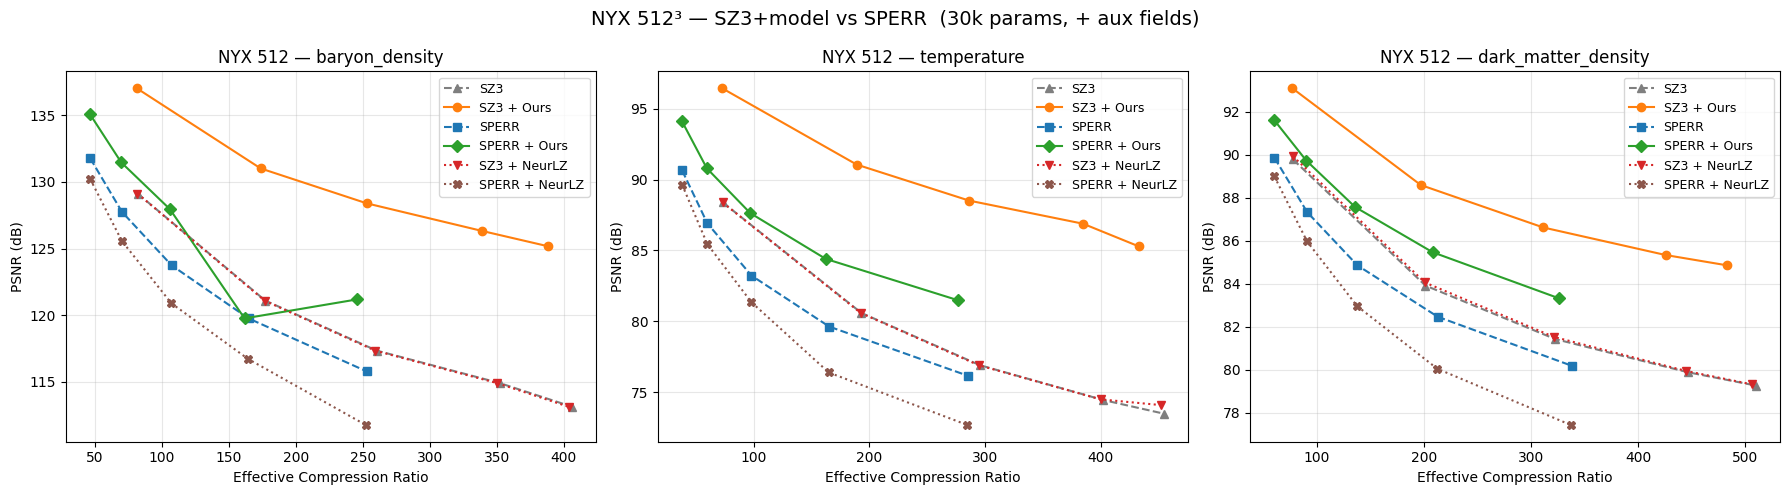

Saved: sperr_cmp_nyx.pdf


In [ ]:
NYX_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
NYX_SHAPE = (512, 512, 512)
NYX_ALL   = ["baryon_density", "dark_matter_density", "temperature",
             "velocity_x", "velocity_y", "velocity_z"]
NYX_TARGETS = ["baryon_density", "temperature", "dark_matter_density"]
# Per-field rel_err: baryon density needs much tighter bounds than temperature /
# dark matter density (different dynamic ranges / compressibility).
NYX_REL = {
    "baryon_density":      [1e-6, 3e-6, 5e-6, 7e-6, 9e-6],
    "temperature":         [1e-4, 3e-4, 5e-4, 7e-4, 8e-4],
    "dark_matter_density": [1e-4, 3e-4, 5e-4, 7e-4, 8e-4],
}
NYX_PARAMS, NYX_EPOCHS, NYX_SPERR_OFF = 30000, 10, 19.0
NYX_SPERR_EXTRA_SPAN, NYX_SPERR_NEXTRA = 7, 0   # 5 rel + 2 extra = 7 SPERR points

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, tname in enumerate(NYX_TARGETS):
    tgt = np.fromfile(NYX_DIR + tname + ".f32", dtype=np.float32).reshape(NYX_SHAPE)
    aux = [np.memmap(NYX_DIR + a + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
           for a in NYX_ALL if a != tname]
    r = cached_bench_field(f"NYX/{tname}", tgt, NYX_DIR + tname + ".f32", aux, NYX_SHAPE,
                    NYX_REL[tname], NYX_PARAMS, NYX_EPOCHS, sperr_psnr_offset=NYX_SPERR_OFF,
                    sperr_extra_span=NYX_SPERR_EXTRA_SPAN, sperr_n_extra=NYX_SPERR_NEXTRA)
    plot_panel(axes[i], r, f"NYX 512 — {tname}")
    del tgt, aux
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig.suptitle("NYX 512³ — SZ3+model vs SPERR  (30k params, + aux fields)", fontsize=14)
plt.tight_layout()
plt.savefig("sperr_cmp_nyx.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_nyx.pdf")

captured 3 NYX panels from `axes` ([6, 6, 6] curves each)


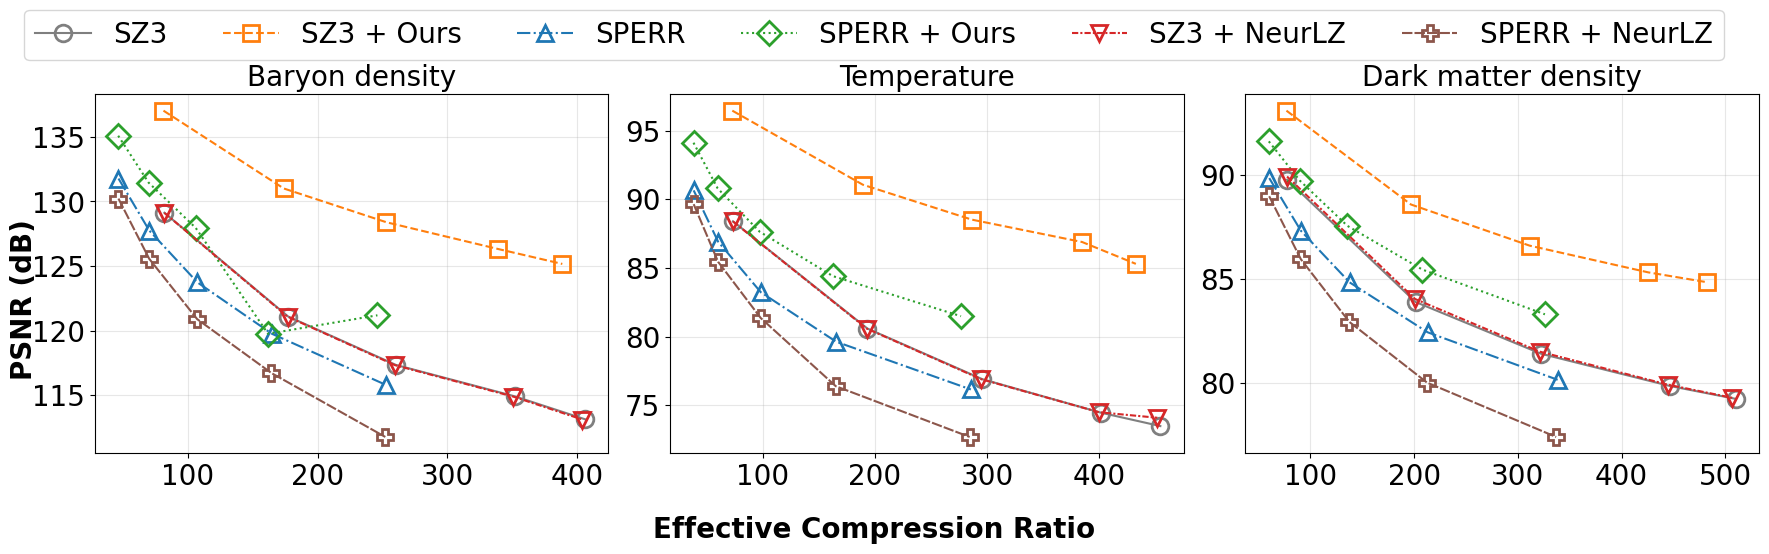

Saved: sperr_cmp_nyx.pdf


In [6]:
# ── Restyle the NYX figure WITHOUT retraining ─────────────────────────────────
# The training cell above didn't keep the per-target results (it reused `r`), but its
# 3 subplots are still in memory as `axes`. We pull each curve's data/style out of
# those axes ONCE (cached in NYX_PANELS so re-running this cell is free), then redraw
# with a fully editable figure config. No `bench_field` call -> no retraining.
def plot_panel(ax, r, title):
    ax.plot(r["sz3"]["CR"], r["sz3"]["PSNR"], "^--", color="tab:gray", label="SZ3")
    ax.plot(r["pipe"]["CR"], r["pipe"]["PSNR"], "o-", color="tab:orange",
            label=f"SZ3 + Ours")
    ax.plot(r["sperr"]["CR"], r["sperr"]["PSNR"], "s--", color="tab:blue", label="SPERR")
    ax.plot(r["sperr_pipe"]["CR"], r["sperr_pipe"]["PSNR"], "D-", color="tab:green",
            label="SPERR + Ours")
    if r.get("neurlz", {}).get("CR"):
        ax.plot(r["neurlz"]["CR"], r["neurlz"]["PSNR"], "v:", color="tab:red", label="SZ3 + NeurLZ")
    if r.get("sperr_neurlz", {}).get("CR"):
        ax.plot(r["sperr_neurlz"]["CR"], r["sperr_neurlz"]["PSNR"], "X:", color="tab:brown",
                label="SPERR + NeurLZ")
    if r.get("slab", {}).get("CR"):
        ax.plot(r["slab"]["CR"], r["slab"]["PSNR"], "P-", color="purple", label="SZ3 + Ours 2.5D (slab)")
    ax.set_xlabel("Effective Compression Ratio"); ax.set_ylabel("PSNR (dB)")
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)



# ---- capture the plotted curves once (survives re-running THIS cell) ----------
if "NYX_PANELS" not in globals():
    assert "axes" in globals(), "Run the NYX training cell first (need its `axes`)."
    NYX_PANELS = []
    for ax in np.ravel(axes):
        lines = [dict(x=list(ln.get_xdata()), y=list(ln.get_ydata()),
                      label=ln.get_label(), color=ln.get_color(),
                      marker=ln.get_marker(), ls=ln.get_linestyle(),
                      lw=float(ln.get_linewidth()), ms=float(ln.get_markersize()))
                 for ln in ax.get_lines()]
        NYX_PANELS.append(dict(title=ax.get_title(), lines=lines))
    print(f"captured {len(NYX_PANELS)} NYX panels from `axes` "
          f"({[len(p['lines']) for p in NYX_PANELS]} curves each)")

# ---- FIGURE CONFIG (edit freely, then re-run this cell) -----------------------
FIGSIZE      = (18, 5)
DPI          = 150
TITLE_FS     = 20
LABEL_FS     = 20
TICK_FS      = 20
LEGEND_FS    = 20

# 增大 Marker
MARKER_SCALE = 2.0          # 原为 1.0，调大该值使 marker 变大
LINE_SCALE   = 1.0          # >1 to thicken lines
GRID_ALPHA   = 0.30
XLOG         = False        # True -> log x (compression ratio)
XLABEL       = "Effective Compression Ratio"
YLABEL       = "PSNR (dB)"
SUPTITLE     = "NYX 512³ — SZ3+model vs SPERR  (30k params, + aux fields)"
SUPTITLE_FS  = 16

# 自定义线型和标记形状列表（你可以随时在这里更改并重新运行）
CUSTOM_MARKERS    = ["o", "s", "^", "D", "v", "P", "*", "X"]
CUSTOM_LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))]

# 图例文字（按曲线顺序,直接在这里改就会生效;None = 用捕获到的原 label）
# 顺序: SZ3, SZ3+model, SPERR, SPERR+model, SZ3+NeurLZ, SPERR+NeurLZ [, slab]
CUSTOM_LABELS = ["SZ3", "SZ3 + Ours", "SPERR", "SPERR + Ours",
                 "SZ3 + NeurLZ", "SPERR + NeurLZ"]

# per-panel titles: None = keep original; or override e.g.
Title = ["Baryon density", "Temperature", "Dark matter density"]
PANEL_TITLES = Title
SAVE_NAME    = "sperr_cmp_nyx.pdf"     # .pdf or .png

titles = PANEL_TITLES or [p["title"] for p in NYX_PANELS]
fig2, axes2 = plt.subplots(1, len(NYX_PANELS), figsize=FIGSIZE)
axes2 = np.ravel(axes2)

for ax_idx, (ax, panel, title) in enumerate(zip(axes2, NYX_PANELS, titles)):
    for i, ln in enumerate(panel["lines"]):
        
        # 使用 enumerate 获取索引 i，按顺序分配新的 marker 和 linestyle
        m = CUSTOM_MARKERS[i % len(CUSTOM_MARKERS)]
        ls = CUSTOM_LINESTYLES[i % len(CUSTOM_LINESTYLES)]
        
        # 加入 markerfacecolor='none' 画空心形状，并用 markeredgewidth=2.0 保证线条清晰
        lbl = (CUSTOM_LABELS[i] if CUSTOM_LABELS and i < len(CUSTOM_LABELS)
               else ln["label"])
        ax.plot(ln["x"], ln["y"], color=ln["color"], marker=m,
                linestyle=ls, linewidth=ln["lw"] * LINE_SCALE,
                markersize=ln["ms"] * MARKER_SCALE, label=lbl,
                markerfacecolor='none', markeredgewidth=2.0)
                
    if XLOG:
        ax.set_xscale("log")
    
    ax.set_title(title, fontsize=TITLE_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.grid(True, alpha=GRID_ALPHA)
    
fig2.supxlabel(XLABEL, fontsize=LABEL_FS, fontweight='bold')
fig2.supylabel(YLABEL, fontsize=LABEL_FS, fontweight='bold')
# fig2.suptitle(SUPTITLE, fontsize=SUPTITLE_FS)

# 【修改】获取第一张图的句柄和标签，放到整个 Figure 上方居中
handles, labels = axes2[0].get_legend_handles_labels()
# bbox_to_anchor=(0.5, 1.05) 表示以横向居中(0.5)，纵向稍微高出图表(1.05)作为锚点
# loc='lower center' 表示图例框的下中心点对准上述锚点
fig2.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.95), 
            fontsize=LEGEND_FS, ncol=len(labels), frameon=True)

plt.tight_layout()
plt.savefig(SAVE_NAME, dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved:", SAVE_NAME)


## A/B — fp32 training (`cfg.amp=False`) vs bf16 AMP

Same data / params / epochs / seed — **only the AMP dtype differs** — on the tightest-bound (highest-PSNR) NYX point, where bf16's ~7-bit mantissa is most likely to cap precision. Reports the PSNR gain from fp32 and its wall-clock cost. Change `AB_FIELD` / `AB_REL` to probe other operating points (e.g. `baryon_density` @ `1e-6` is even higher-PSNR).

In [7]:
# # ============================================================================
# # A/B: does fp32 training (cfg.amp=False) beat bf16 AMP on PSNR?
# # Only cfg.amp differs; train_bg_only seeds internally (cfg.seed) so init +
# # sampling are identical between the two runs -> the delta is purely fp32 vs bf16.
# # Uses final-epoch weights (evaluator=None) for speed; the relative gap is what matters.
# # ============================================================================
# import time

# AB_FIELD  = "baryon_density"   # try "baryon_density" + AB_REL=1e-6 for an even higher-PSNR point
# AB_REL    = 5e-6                    # tightest bound for this field -> highest PSNR -> most precision-limited
# AB_PARAMS = NYX_PARAMS             # 30k
# AB_EPOCHS = NYX_EPOCHS             # 10
# AB_USE_AUX = True                  # match the main NYX run (aux fields as extra input channels)

# tgt = np.fromfile(NYX_DIR + AB_FIELD + ".f32", dtype=np.float32).reshape(NYX_SHAPE)
# aux = ([np.memmap(NYX_DIR + a + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
#         for a in NYX_ALL if a != AB_FIELD] if AB_USE_AUX else [])
# drange   = float(tgt.max() - tgt.min())
# n_fields = 1 + len(aux)
# bg_h     = bg_h_for_params(AB_PARAMS, NYX_SHAPE, n_fields)
# n_params, nn_bytes = estimate_bg_model_param_bytes(
#     n_fields=n_fields, shape=NYX_SHAPE, bg_arch="spatial", bg_h=bg_h, dtype_bytes=BYTES_PER_PARAM)
# depth, patch = NYX_SHAPE[0], NYX_SHAPE[2]
# orig_bytes   = int(np.prod(NYX_SHAPE)) * 4

# b, _   = sz_engine.compress(tgt, 1, 0, float(AB_REL), 0)
# sz_len = len(b)
# xq     = sz_engine.decompress(b, NYX_SHAPE, np.float32)
# p_sz3  = compute_psnr(tgt, xq, drange)
# cr_pipe = orig_bytes / (sz_len + nn_bytes)
# print(f"[A/B] {AB_FIELD} rel={AB_REL:.0e} | bg_h={bg_h} (~{n_params:,}p) | "
#       f"SZ3 base PSNR={p_sz3:.2f} dB | pipe CR~{cr_pipe:.1f}x | aux={len(aux)} | epochs={AB_EPOCHS}")

# def _train_amp(use_amp):
#     Xs  = [tgt] + aux
#     Xps = [np.ascontiguousarray(xq, np.float32)] + aux
#     cfg = build_bg_only_cfg(
#         X_target=Xs[0], Xps=Xps, max_train_time=1e9, bg_h=bg_h, roi_h=4,
#         epochs=AB_EPOCHS, steps_per_epoch=depth, bg_patch_size=patch, bg_batch=1, lr=1e-3,
#         bg_freq_weight=1.0, bg_fft_phase_weight=1.0, bg_freq_warmup_epochs=1,
#         bg_field_norm="zscore")
#     cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
#     cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
#     cfg.bg_gpu_sampling = True
#     cfg.amp = bool(use_amp)                       # <-- the only knob that differs
#     cfg.seed = SEED
#     t0 = time.time()
#     model, _ = train_bg_only(Xs=Xs, Xps=Xps, device=device, cfg=cfg, evaluator=None)
#     xh = run_bg_inference(unwrap_bg_model(model), Xs, Xps, cfg, float(AB_REL))
#     p  = compute_psnr(Xs[0], xh, drange)
#     wall = time.time() - t0
#     del model
#     torch.cuda.empty_cache() if torch.cuda.is_available() else None
#     return p, wall

# p_bf16, t_bf16 = _train_amp(True)
# p_fp32, t_fp32 = _train_amp(False)

# print("\n========== fp32 vs bf16 (same seed / params / epochs) ==========")
# print(f"  SZ3 base           : {p_sz3:7.2f} dB")
# print(f"  SZ3+model (bf16)   : {p_bf16:7.2f} dB  (+{p_bf16 - p_sz3:5.2f} over SZ3)  [{t_bf16:.0f}s]")
# print(f"  SZ3+model (fp32)   : {p_fp32:7.2f} dB  (+{p_fp32 - p_sz3:5.2f} over SZ3)  [{t_fp32:.0f}s]")
# print(f"  >> fp32 - bf16     : {p_fp32 - p_bf16:+.3f} dB   (PSNR gain from fp32 training)")
# print(f"  >> fp32 slowdown   : {t_fp32 / max(t_bf16, 1e-9):.2f}x wall")
# del tgt, aux, xq
# torch.cuda.empty_cache() if torch.cuda.is_available() else None


## 2. Miranda 1024³  —  single field (240k params)

In [8]:
MIR_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/miranda_1024x1024x1024_float32.raw"
MIR_SHAPE = (1024, 1024, 1024)
MIR_REL   = [5e-3, 7e-3, 9e-3, 1e-2, 1.5e-2]
MIR_PARAMS, MIR_EPOCHS = 240000, 5

mir = np.fromfile(MIR_FILE, dtype=np.float32).reshape(MIR_SHAPE)   # ~4 GB in RAM
r = cached_bench_field("Miranda", mir, MIR_FILE, [], MIR_SHAPE, MIR_REL, MIR_PARAMS, MIR_EPOCHS)
MIRANDA_R = r   # keep Miranda results for the restyle cell below (no retrain)
del mir
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "Miranda 1024³ — single field")
fig.suptitle("Miranda 1024³ — SZ3+model vs SPERR  (240k params)", fontsize=13)
plt.tight_layout()
plt.savefig("sperr_cmp_miranda.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_miranda.pdf")

[cache] MISS Miranda: training ...

[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) Network : 9,688 parameters

[Model: spatial] Total Params: 11,314
 [Params] Main (BG) Network : 11,314 parameters

[Model: spatial] Total Params: 

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


  [TPE] band=5.0e-03 10 trials -> PICK axis2 lr=3.0e-03 proxy=57.39 gain=+3.04 | axis0:56.7@1e-03 axis1:57.2@1e-03 axis2:57.4@3e-03

[Model: spatial] Total Params: 237,538
 [Params] Main (BG) Network : 237,538 parameters
[Init] Epoch   0 | Global PSNR: 54.94 dB | MaxErr: 0.0
[plan] pure_train_budget=1000000000.00s | epochs_cap=5 | steps/epoch=1024 | patch=1024 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 1 fields resident on cuda:0 (~8.6 GB)
Epoch   1 [BG] | train_wall=23.39s | Loss: 1.470725 | Freq: 1.589630 | Low: 0.113155 | Mid: 0.121943 | High: 0.381942 | Global: 54.94 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈23.958s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=21.72s | Loss: 1.485719 | Freq: 0.575600 | Low: 0.127983 | Mid: 0.123136 | High: 0.254385 | Global: 57.01 dB | MaxErr: 0.0  [New Best!]
Epoch   3 [BG] | train_wall=21.76s | Loss: 0.993478 | Freq

KeyboardInterrupt: 

In [ ]:
# ── Restyle the Miranda figure WITHOUT retraining (matches the NYX look) ──────
# Reads Miranda's results dict MIRANDA_R (set in the Miranda cell), so re-running
# this cell to tweak style costs nothing (no bench_field / no 1024³ retrain).
# Same hollow-marker + custom-linestyle config as the NYX restyle.
assert "MIRANDA_R" in globals(), "Run the Miranda training cell first (need MIRANDA_R)."

# ---- FIGURE CONFIG (edit freely, then re-run this cell) ----------------------
FIGSIZE_M     = (8, 6)
DPI_M         = 150
TITLE_FS_M    = 20
LABEL_FS_M    = 20
TICK_FS_M     = 18
LEGEND_FS_M   = 13
MARKER_BASE_M = 6           # base marker size
MARKER_SCALE_M = 2.0        # >1 enlarges markers (NYX used 2.0)
LINE_SCALE_M  = 1.0
GRID_ALPHA_M  = 0.30
XLOG_M        = False
PANEL_TITLE_M = "Miranda 1024³"
LEGEND_LOC_M  = "best"      # e.g. "lower left", "upper right"
SAVE_NAME_M   = "sperr_cmp_miranda.pdf"

CUSTOM_MARKERS_M    = ["o", "s", "^", "D", "v", "P", "*", "X"]
CUSTOM_LINESTYLES_M = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))]

# curve order / label / color  (same mapping as plot_panel)
_npk = MIRANDA_R.get("n_params", 0) / 1000.0
SERIES_M = [
    ("sz3",          "SZ3",                        "tab:gray"),
    ("pipe",         f"SZ3 + Ours", "tab:orange"),
    ("sperr",        "SPERR",                      "tab:blue"),
    ("sperr_pipe",   "SPERR + Ours",              "tab:green"),
    ("neurlz",       "SZ3 + NeurLZ",               "tab:red"),
    ("sperr_neurlz", "SPERR + NeurLZ",             "tab:brown"),
    ("slab",         "SZ3 + model 2.5D (slab)",    "purple"),
]

figM, axM = plt.subplots(figsize=FIGSIZE_M)
i = 0
for key, label, color in SERIES_M:
    d = MIRANDA_R.get(key, {})
    if not d.get("CR"):
        continue
    m  = CUSTOM_MARKERS_M[i % len(CUSTOM_MARKERS_M)]
    ls = CUSTOM_LINESTYLES_M[i % len(CUSTOM_LINESTYLES_M)]
    axM.plot(d["CR"], d["PSNR"], color=color, marker=m, linestyle=ls,
             linewidth=1.8 * LINE_SCALE_M,
             markersize=MARKER_BASE_M * MARKER_SCALE_M,
             markerfacecolor="none", markeredgewidth=2.0, label=label)
    i += 1

if XLOG_M:
    axM.set_xscale("log")
axM.set_xlabel("Effective Compression Ratio", fontsize=LABEL_FS_M, fontweight="bold")
axM.set_ylabel("PSNR (dB)", fontsize=LABEL_FS_M, fontweight="bold")
axM.set_title(PANEL_TITLE_M, fontsize=TITLE_FS_M)
axM.tick_params(axis="both", labelsize=TICK_FS_M)
axM.grid(True, alpha=GRID_ALPHA_M)
axM.legend(fontsize=LEGEND_FS_M, loc=LEGEND_LOC_M, frameon=True)

plt.tight_layout()
plt.savefig(SAVE_NAME_M, dpi=DPI_M, bbox_inches="tight")
plt.show()
print("Saved:", SAVE_NAME_M)


## 3. Hurricane 100×500×500  —  CLOUD (6k params, +aux: PRECIP,P,TC,U,V,W)

In [ ]:
HUR_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/100x500x500/"
HUR_SHAPE = (100, 500, 500)
HUR_TARGET = "CLOUDf48"
HUR_AUX    = [ "Vf48",  "TCf48",
               "Uf48", "PRECIPf48", "Wf48"]   # all 5 non-target fields (CF mode)
HUR_REL    = [1e-2, 2e-2, 3e-2, 4e-2, 6e-2]
HUR_PARAMS, HUR_EPOCHS = 6500, 100

tgt = np.fromfile(HUR_DIR + HUR_TARGET + ".bin.f32", dtype=np.float32).reshape(HUR_SHAPE)
aux = [np.memmap(HUR_DIR + a + ".bin.f32", dtype=np.float32, mode="r", shape=HUR_SHAPE)
       for a in HUR_AUX]
r = cached_bench_field("Hurricane/CLOUD", tgt, HUR_DIR + HUR_TARGET + ".bin.f32", aux, HUR_SHAPE,
                HUR_REL, HUR_PARAMS, HUR_EPOCHS,
                full_slice=True, full_slice_axis=0)   # slice along z (axis 0) -> full 500x500 xy-planes (xyz/yxz order)
del tgt, aux
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "Hurricane — CLOUD (+aux)")
fig.suptitle("Hurricane 100×500×500 CLOUD — SZ3+model vs SPERR  (6k params, +12 aux / CF)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_hurricane.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_hurricane.png")

### Hurricane — NO aux (single-field): my pipeline vs NeurLZ head-to-head
Same target/rels/budget/epochs as above, but **`aux=[]`** so the BG model also sees only CLOUD (`in_channels=1`) — a like-for-like single-field comparison against NeurLZ (which is already single-field).

In [ ]:
# ── Hurricane CLOUD — NO aux: BG pipeline AND NeurLZ both single-field ─────────
# aux=[] -> the BG model sees only CLOUD (in_channels=1), head-to-head vs NeurLZ.
# (Reuses HUR_* from the cell above; reload tgt since that cell deletes it.)
tgt = np.fromfile(HUR_DIR + HUR_TARGET + ".bin.f32", dtype=np.float32).reshape(HUR_SHAPE)
set_seed(SEED)
r_hur_noaux = cached_bench_field("Hurricane/CLOUD (no aux)", tgt, HUR_DIR + HUR_TARGET + ".bin.f32", [],
                          HUR_SHAPE, HUR_REL, HUR_PARAMS, HUR_EPOCHS,
                          full_slice=True, full_slice_axis=0)   # slice along z (axis 0)
del tgt
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r_hur_noaux, "Hurricane — CLOUD (no aux)")
fig.suptitle("Hurricane 100×500×500 CLOUD (NO aux) — SZ3+model vs SPERR  (6k params)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_hurricane_noaux.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_hurricane_noaux.pdf")


## 4. Magnetic Reconnection 512³  —  single field (30k params)

In [ ]:
MAG_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/magnetic_reconnection_512x512x512_float32.raw"
MAG_SHAPE = (512, 512, 512)
MAG_REL   = [1e-3, 3e-3, 5e-3, 7e-3]
MAG_PARAMS, MAG_EPOCHS = 30000, 20

mag = np.fromfile(MAG_FILE, dtype=np.float32).reshape(MAG_SHAPE)
r = cached_bench_field("Magnetic", mag, MAG_FILE, [], MAG_SHAPE, MAG_REL, MAG_PARAMS, MAG_EPOCHS)
del mag
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "Magnetic Reconnection 512³ — single field")
fig.suptitle("Magnetic Reconnection 512³ — SZ3+model vs SPERR  (30k params)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_magnetic.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_magnetic.pdf")

WPX

In [ ]:
# ── wpx 256×256×2048 (double) ────────────────────────────────────────────────
WPX_RAW       = "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw"
WPX_SRC_SHAPE = (256, 256, 2048)        # as stored (float64)

# double -> float32 (this notebook trains/compresses in f32); reorient so the
# model's 2-D slices are SQUARE (256×256): move the 2048 axis to depth.
_wpx = np.fromfile(WPX_RAW, dtype=np.float64).reshape(WPX_SRC_SHAPE).astype(np.float32)
_wpx = np.ascontiguousarray(np.transpose(_wpx, (2, 0, 1)))   # -> (2048, 256, 256)
WPX_SHAPE = _wpx.shape

# SPERR reads a file with --ftype 32, so write the reoriented f32 volume for it
WPX_F32 = "/tmp/wpx_2048_256_256_f32.raw"
_wpx.tofile(WPX_F32)

WPX_REL              = [1e-2, 2e-2, 3e-2, 4e-2, 5e-2]
WPX_PARAMS, WPX_EPOCHS = 30000, 20        # depth=2048 → epochs are ~4× Magnetic; lower if slow

set_seed(SEED)
r = cached_bench_field("wpx", _wpx, WPX_F32, [], WPX_SHAPE, WPX_REL, WPX_PARAMS, WPX_EPOCHS,
                       full_slice=True, full_slice_axis=2,
                       bo_axes=[2])   # force axis2: same speed as axis1 (256 steps/ep of
                                       # 2048x256) but clean (axis1 hits WarpX guard-plane
                                       # degenerate slices). axis0 (native square) wins on
                                       # PSNR but is ~7.6x slower/epoch (measured) -- skip it.
del _wpx
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "wpx 256×256×2048 (double→f32)")
fig.suptitle("wpx — SZ3+model vs SPERR  (30k params)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_wpx.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_wpx.pdf")


In [ ]:
# ── S3D 500×500×500 (double) ─────────────────────────────────────────────────
# Combustion volume, single field, stored float64. Convert to float32 (this notebook
# trains/compresses in f32) and also write the f32 volume for SPERR (--ftype 32).
# 500 is divisible by 4, so the 2-downsample spatial UNet handles it with no padding.
S3D_RAW   = "/home/sam/Halo_Finder/halo_finder_v1/s3d-500_500_500-double.raw"
S3D_SHAPE = (500, 500, 500)
S3D_REL   = [1e-5, 3e-5, 5e-5, 7e-5, 9e-5]
S3D_PARAMS, S3D_EPOCHS = 30000, 20

s3d = np.fromfile(S3D_RAW, dtype=np.float64).reshape(S3D_SHAPE).astype(np.float32)
S3D_F32 = "/tmp/s3d_500_500_500_f32.raw"
s3d.tofile(S3D_F32)

r = cached_bench_field("S3D", s3d, S3D_F32, [], S3D_SHAPE, S3D_REL, S3D_PARAMS, S3D_EPOCHS)
S3D_R = r   # keep results for a restyle cell / later use (no retrain)
del s3d
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_panel(ax, r, "S3D 500³ — single field")
fig.suptitle("S3D 500³ — SZ3+model vs SPERR  (30k params)", fontsize=12)
plt.tight_layout()
plt.savefig("sperr_cmp_s3d.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sperr_cmp_s3d.pdf")


In [ ]:
# # ====================================================================================
# # Per-dataset RESIDUAL distributions: raw R=X-X' | after minmax | after zscore
# # R (the SZ3 error) is the model's TARGET / what it predicts; minmax & zscore are the two
# # ways it gets normalized before the loss. Needs SZ3 (compress+decompress) per dataset at
# # a representative rel. Miranda peaks ~8 GB (x + X'); comment it out if RAM is tight.
# # Residual stats are TRUE (chunked); a ~2M subsample is used for the histograms.
# # ====================================================================================
# import numpy as np, matplotlib.pyplot as plt, os
# from pysz import SZ
# _sz_eng = SZ(globals().get("sz_lib_path", "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"))
# _NYX = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"

# # (label, path, raw_dtype, shape, rel)
# RES_DATASETS = [
#     ("NYX/baryon_density",      _NYX + "baryon_density.f32",      np.float32, (512, 512, 512), 1e-4),
#     ("NYX/dark_matter_density", _NYX + "dark_matter_density.f32", np.float32, (512, 512, 512), 1e-4),
#     ("NYX/temperature",         _NYX + "temperature.f32",        np.float32, (512, 512, 512), 1e-4),
#     ("Hurricane/CLOUDf48", "/home/sam/Halo_Finder/halo_finder_v1/100x500x500/CLOUDf48.bin.f32",              np.float32, (100, 500, 500),    1e-3),
#     ("Magnetic",           "/home/sam/Halo_Finder/halo_finder_v1/magnetic_reconnection_512x512x512_float32.raw", np.float32, (512, 512, 512), 1e-3),
#     ("wpx",                "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw",               np.float64, (256, 256, 2048),   1e-3),
#     ("Miranda",            "/home/sam/Halo_Finder/halo_finder_v1/miranda_1024x1024x1024_float32.raw",        np.float32, (1024, 1024, 1024), 1e-3),
# ]

# def _resid_stats_sample(x, xp, n_sample=2_000_000, chunk=8_000_000):
#     n = x.size; xf = x.ravel(); xpf = xp.ravel()
#     s = ss = 0.0; vmin = np.inf; vmax = -np.inf
#     stride = max(1, n // n_sample); samp = []
#     for i in range(0, n, chunk):
#         rc = xf[i:i+chunk].astype(np.float64) - xpf[i:i+chunk].astype(np.float64)
#         s += rc.sum(); ss += (rc*rc).sum()
#         vmin = min(vmin, rc.min()); vmax = max(vmax, rc.max()); samp.append(rc[::stride])
#     mean = s/n; std = max(ss/n - mean*mean, 0.0) ** 0.5
#     return vmin, vmax, mean, std, np.concatenate(samp)

# avail = [r for r in RES_DATASETS if os.path.exists(r[1])]
# nrow = len(avail)
# fig, axes = plt.subplots(nrow, 3, figsize=(14, 2.6 * nrow), dpi=120)
# axes = np.atleast_2d(axes)
# for r, (label, path, dt, shape, rel) in enumerate(avail):
#     x = np.ascontiguousarray(np.fromfile(path, dtype=dt).reshape(shape).astype(np.float32))
#     b, _ = _sz_eng.compress(x, 1, 0, float(rel), 0)
#     xp = _sz_eng.decompress(b, x.shape, np.float32)
#     vmin, vmax, mean, std, R = _resid_stats_sample(x, xp)
#     del x, xp, b
#     rng = (vmax - vmin) or 1.0

#     ax = axes[r, 0]                                   # raw residual, log-y
#     ax.hist(R, bins=120, color="0.5"); ax.set_yscale("log")
#     ax.set_ylabel(f"{label}\nrel={rel:.0e}", fontsize=8)
#     if r == 0: ax.set_title("raw residual  R = X - X'")
#     ax.text(0.97, 0.93, f"min={vmin:.1e}  max={vmax:.1e}\nμ={mean:.1e}  σ={std:.1e}",
#             transform=ax.transAxes, ha="right", va="top", fontsize=7)

#     ax = axes[r, 1]                                   # minmax residual in [0,1], log-y
#     ax.hist((R - vmin) / rng, bins=120, range=(0, 1), color="tab:red"); ax.set_yscale("log")
#     if r == 0: ax.set_title("residual after minmax")
#     ax.text(0.97, 0.93, f"bulk σ={std/rng:.2e}\nmean@{(mean-vmin)/rng:.2f}",
#             transform=ax.transAxes, ha="right", va="top", fontsize=7)

#     ax = axes[r, 2]                                   # zscore residual (full, bounded), log-y
#     ax.hist((R - mean) / std, bins=120, color="tab:blue"); ax.set_yscale("log")
#     if r == 0: ax.set_title("residual after zscore  (units of σ)")
#     ax.text(0.97, 0.93, f"max={(vmax-mean)/std:.1f}σ\nmin={(vmin-mean)/std:.1f}σ",
#             transform=ax.transAxes, ha="right", va="top", fontsize=7)

# fig.suptitle("Per-dataset RESIDUAL (X - X') distributions:  raw  |  minmax  |  zscore", y=1.001, fontsize=12)
# fig.tight_layout()
# plt.show()


In [ ]:
# # ── wpx: NeurLZ vs BG pipeline — PSNR-vs-time + slice viz (one rel) ────────────
# # Re-trains BOTH on a single wpx rel (full 256x2048 planes, slice axis 1), capturing
# # per-epoch (pure-train-time, PSNR) and the final reconstruction, then plots:
# #   (1) PSNR vs wall time   (2) a 2048x256 slice: GT / SZ3 / SZ3+model / SZ3+NeurLZ + residuals
# import matplotlib.pyplot as plt
# WPX_VIZ_REL = WPX_REL[2]          # which rel to visualize
# _PERM = (1, 0, 2)                 # axis1 -> front (self-inverse); planes become (2048, 256)

# # reload wpx (the bench cell deletes _wpx) + SZ3 base at the viz rel
# _wx = np.ascontiguousarray(np.fromfile(WPX_RAW, dtype=np.float64).reshape((2048, 256, 256)).astype(np.float32))
# _dr = float(_wx.max() - _wx.min())
# _b, _ = sz_engine.compress(_wx, 1, 0, float(WPX_VIZ_REL), 0)
# _xq = sz_engine.decompress(_b, _wx.shape, np.float32)

# # ---- BG pipeline (full-slice along axis 1 -> 2048x256 planes) ----
# Xs_bg  = [np.ascontiguousarray(np.transpose(_wx,  _PERM))]   # (256, 2048, 256)
# Xps_bg = [np.ascontiguousarray(np.transpose(_xq, _PERM))]
# _bgh = bg_h_for_params(WPX_PARAMS, _wx.shape, 1)
# _np, _ = estimate_bg_model_param_bytes(n_fields=1, shape=_wx.shape, bg_arch="spatial", bg_h=_bgh,
#                                        dtype_bytes=BYTES_PER_PARAM)
# _cfg = build_bg_only_cfg(X_target=Xs_bg[0], Xps=Xps_bg, max_train_time=1e9, bg_h=_bgh, roi_h=4,
#                          epochs=WPX_EPOCHS, steps_per_epoch=Xs_bg[0].shape[0], bg_patch_size=256,
#                          bg_batch=1, lr=1e-3, bg_freq_weight=0.5, bg_fft_phase_weight=0.5,
#                          bg_freq_warmup_epochs=1, bg_field_norm="zscore")
# _cfg.bg_arch="spatial"; _cfg.bg_split_mode="three"; _cfg.bg_split_bands=True
# _cfg.bg_split_sigma=0.12; _cfg.bg_sigma_low=0.08; _cfg.bg_sigma_mid=0.18
# _cfg.bg_cr_rel_err=float(WPX_VIZ_REL); _cfg.bg_gpu_sampling=True; _cfg.seed=SEED
# _cfg.bg_full_slice=True; _cfg.bg_low_weight=1.0; _cfg.bg_mid_weight=0.5; _cfg.bg_high_weight=0.3
# def _ev(m, c=_cfg):
#     return compute_psnr(Xs_bg[0], run_bg_inference(m, Xs_bg, Xps_bg, c, float(WPX_VIZ_REL)), _dr), 0.0
# print(f"[viz] training BG pipeline (rel={WPX_VIZ_REL:.0e}, {_np:,} params)...")
# _model, _hist = train_bg_only(Xs=Xs_bg, Xps=Xps_bg, device=device, cfg=_cfg, evaluator=_ev)
# bg_t = list(_hist.get("time", []))
# bg_p = [(v[1] if isinstance(v, (tuple, list)) else float(v)) for v in _hist.get("psnr", [])]
# _m = min(len(bg_t), len(bg_p)); bg_t, bg_p = bg_t[:_m], bg_p[:_m]
# xhat_bg = run_bg_inference(_model, Xs_bg, Xps_bg, _cfg, float(WPX_VIZ_REL))   # (256,2048,256)
# del _model
# torch.cuda.empty_cache() if torch.cuda.is_available() else None

# # ---- NeurLZ (same slicing axis; iso-time budget = BG's total; returns history + recon) ----
# _feat = (_neurlz_features_for_params(_np, 1) if NEURLZ_FEATURES == "match" else NEURLZ_FEATURES)
# _budget = bg_t[-1] if bg_t else None
# print(f"[viz] training NeurLZ (slice_axis=1, budget={_budget:.1f}s)...")
# p_nlz, nlz_params, nlz_time, nlz_ep, nlz_hist, enh_nlz = run_neurlz(
#     _wx, _xq, [], _wx.shape, _dr, float(WPX_VIZ_REL),
#     int(WPX_EPOCHS * NEURLZ_EPOCH_MULT), _feat, time_budget=_budget, slice_axis=1, return_history=True)
# # enh_nlz is in the permuted frame (256,2048,256), same as Xs_bg

# base_psnr = compute_psnr(Xs_bg[0], Xps_bg[0], _dr)

# # ---- (1) PSNR vs time ----
# plt.figure(figsize=(7.5, 5), dpi=130)
# plt.axhline(base_psnr, color="tab:gray", ls="--", lw=1.5, label=f"SZ3 base ({base_psnr:.1f} dB)")
# plt.plot(bg_t, bg_p, "o-", color="tab:orange", lw=2, label=f"SZ3 + model ({_np:,}p)")
# plt.plot(nlz_hist["time"], nlz_hist["psnr"], "v:", color="tab:red", lw=2, label=f"SZ3 + NeurLZ ({nlz_params:,}p)")
# plt.xlabel("Pure training wall time (s)"); plt.ylabel("Global PSNR (dB)")
# plt.title(f"wpx — PSNR vs time | rel={WPX_VIZ_REL:.0e} (256x2048 slices)")
# plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# # ---- (2) slice viz: a 2048x256 plane (shown transposed = 256x2048 wide) ----
# _z = Xs_bg[0].shape[0] // 2
# gt, base, bg, nlz = Xs_bg[0][_z], Xps_bg[0][_z], xhat_bg[_z], enh_nlz[_z]
# vmin, vmax = float(np.percentile(gt, 1)), float(np.percentile(gt, 99))
# rmax = float(np.max(np.abs(gt - base))) or 1e-9
# fig, ax = plt.subplots(2, 4, figsize=(20, 5), dpi=120)
# for k, (nm, im) in enumerate([("GT", gt), ("SZ3 base", base), ("SZ3+model", bg), ("SZ3+NeurLZ", nlz)]):
#     ax[0, k].imshow(im.T, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
#     ax[0, k].set_title(nm); ax[0, k].axis("off")
# ax[1, 0].axis("off")
# for k, (nm, im) in enumerate([("GT - SZ3", gt - base), ("GT - model", gt - bg), ("GT - NeurLZ", gt - nlz)]):
#     a = ax[1, k + 1]; a.imshow(im.T, cmap="coolwarm", vmin=-rmax, vmax=rmax, aspect="auto")
#     a.set_title(f"{nm}  (|max|={np.max(np.abs(im)):.2e})"); a.axis("off")
# fig.suptitle(f"wpx slice z={_z} — 2048x256 plane (transposed) | rel={WPX_VIZ_REL:.0e} | "
#              f"model {compute_psnr(gt,bg,_dr):.1f}dB  NeurLZ {compute_psnr(gt,nlz,_dr):.1f}dB  base {compute_psnr(gt,base,_dr):.1f}dB", fontsize=11)
# plt.tight_layout(); plt.show()
# del _wx, _xq, Xs_bg, Xps_bg, xhat_bg, enh_nlz
# torch.cuda.empty_cache() if torch.cuda.is_available() else None


In [ ]:
# # ============================================================================
# # Why does the 2.5D slab help wpx but not NYX / Miranda / Magnetic Reconnection?
# # ----------------------------------------------------------------------------
# # KEY: the slab block always stacks its K neighbor slices along AXIS 0 (depth) for
# # every dataset (it does NOT use full_slice_axis). So the slab only helps when the
# # SZ3 residual R = X - X' is more correlated along AXIS 0 than within the slab's own
# # (axis1, axis2) plane -- that is the new context the plain 2D model can't see.
# # We report the lag-1 Pearson correlation of R along each axis, then:
# #   * cross-slice = corr along axis 0           (the slab's stacking axis)
# #   * in-plane    = mean corr along axes 1, 2   (the slab's 2D plane)
# #   * ratio       = cross / in-plane.  High cross AND ratio >> 1  =>  slab helps.
# # Note: wpx is reoriented to (2048,256,256) exactly as the bench loads it, so axis 0
# # is the long, smooth beam-propagation direction. Measured on a centered sub-cube.
# NYX_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
# NYX_SHAPE = (512, 512, 512)
# NYX_ALL   = ["baryon_density", "dark_matter_density", "temperature",
#              "velocity_x", "velocity_y", "velocity_z"]
# NYX_TARGETS = ["baryon_density", "temperature", "dark_matter_density"]
# # Per-field rel_err: baryon density needs much tighter bounds than temperature /
# # dark matter density (different dynamic ranges / compressibility).
# NYX_REL = {
#     "baryon_density":      [1e-6, 3e-6, 5e-6, 7e-6, 9e-6],
#     "temperature":         [1e-4, 3e-4, 5e-4, 7e-4, 9e-4],
#     "dark_matter_density": [1e-4, 3e-4, 5e-4, 7e-4, 9e-4],
# }
# NYX_PARAMS, NYX_EPOCHS, NYX_SPERR_OFF = 30000, 20, 20.0
# NYX_SPERR_EXTRA_SPAN, NYX_SPERR_NEXTRA = 8.0, 0   # 5 rel + 2 extra = 7 SPERR points

# MIR_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/miranda_1024x1024x1024_float32.raw"
# MIR_SHAPE = (1024, 1024, 1024)
# MIR_REL   = [1e-3, 3e-3, 5e-3, 7e-3, 9e-3]
# MIR_PARAMS, MIR_EPOCHS = 240000, 10


# HUR_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/100x500x500/"
# HUR_SHAPE = (100, 500, 500)
# HUR_TARGET = "CLOUDf48"
# HUR_AUX    = ["PRECIPf48", "Pf48", "TCf48", "Uf48", "Vf48", "Wf48"]
# HUR_REL    = [1e-3, 2e-3, 3e-3, 4e-3, 6e-3]
# HUR_PARAMS, HUR_EPOCHS = 6000, 20

# MAG_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/magnetic_reconnection_512x512x512_float32.raw"
# MAG_SHAPE = (512, 512, 512)
# MAG_REL   = [1e-3, 3e-3, 5e-3, 7e-3]
# MAG_PARAMS, MAG_EPOCHS = 30000, 20


# # ── wpx 256×256×2048 (double) ────────────────────────────────────────────────
# WPX_RAW       = "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw"
# WPX_SRC_SHAPE = (256, 256, 2048)        # as stored (float64)

# # double -> float32 (this notebook trains/compresses in f32); reorient so the
# # model's 2-D slices are SQUARE (256×256): move the 2048 axis to depth.
# _wpx = np.fromfile(WPX_RAW, dtype=np.float64).reshape(WPX_SRC_SHAPE).astype(np.float32)
# _wpx = np.ascontiguousarray(np.transpose(_wpx, (1, 0, 2)))   # -> (2048, 256, 256)
# WPX_SHAPE = _wpx.shape

# # SPERR reads a file with --ftype 32, so write the reoriented f32 volume for it
# WPX_F32 = "/tmp/wpx_2048_256_256_f32.raw"
# _wpx.tofile(WPX_F32)

# WPX_REL              = [1e-2, 2e-2, 3e-2, 4e-2, 5e-2]
# WPX_PARAMS, WPX_EPOCHS = 30000, 20     


# import numpy as np, pandas as pd

# CORR_CROP = 384   # centered sub-cube side used for the residual-correlation probe
# SLAB_AXIS = 0     # the slab2d path stacks neighbor slices along this axis for all datasets

# def _lag1_corr(R, ax):
#     a = np.moveaxis(R, ax, 0)
#     x = a[:-1].reshape(-1).astype(np.float64); y = a[1:].reshape(-1).astype(np.float64)
#     xs, ys = x.std(), y.std()
#     if xs < 1e-12 or ys < 1e-12:
#         return float("nan")
#     return float(((x - x.mean()) * (y - y.mean())).mean() / (xs * ys))

# def _residual_corr(name, vol, rel, crop=CORR_CROP):
#     sl = tuple(slice((d - min(crop, d)) // 2, (d - min(crop, d)) // 2 + min(crop, d)) for d in vol.shape)
#     sub = np.ascontiguousarray(np.asarray(vol[sl], np.float32))
#     b, _ = sz_engine.compress(sub, 1, 0, float(rel), 0)
#     R = sub - sz_engine.decompress(b, sub.shape, np.float32)
#     corrs = [_lag1_corr(R, ax) for ax in range(3)]
#     cross = corrs[SLAB_AXIS]
#     inplane = float(np.nanmean([corrs[ax] for ax in range(3) if ax != SLAB_AXIS]))
#     return dict(dataset=name, sub_shape=tuple(sub.shape), rel=float(rel),
#                 corr_ax0=corrs[0], corr_ax1=corrs[1], corr_ax2=corrs[2],
#                 cross_slice=cross, in_plane=inplane,
#                 ratio=(cross / inplane if inplane else float("nan")))

# _rows = []
# # --- NYX — 3 targets at their tightest rel
# for _t in ["baryon_density", "temperature", "dark_matter_density"]:
#     _v = np.memmap(NYX_DIR + _t + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
#     _rows.append(_residual_corr(f"NYX/{_t}", _v, NYX_REL[_t][0])); del _v
# # --- Miranda
# _v = np.memmap(MIR_FILE, dtype=np.float32, mode="r", shape=MIR_SHAPE)
# _rows.append(_residual_corr("Miranda", _v, MIR_REL[0])); del _v
# # --- Magnetic Reconnection
# _v = np.memmap(MAG_FILE, dtype=np.float32, mode="r", shape=MAG_SHAPE)
# _rows.append(_residual_corr("Magnetic", _v, MAG_REL[0])); del _v
# # --- wpx: reorient to (2048,256,256) (axis 0 = beam axis), exactly as the bench does
# _v = np.memmap(WPX_RAW, dtype=np.float64, mode="r", shape=WPX_SRC_SHAPE)
# _v = np.ascontiguousarray(np.transpose(_v, (2, 0, 1)).astype(np.float32))
# _rows.append(_residual_corr("wpx", _v, WPX_REL[0])); del _v

# corr_df = pd.DataFrame(_rows)
# corr_df["slab_verdict"] = np.where(corr_df["ratio"] >= 1.5, "helps (axis-0 context)",
#                           np.where(corr_df["ratio"] >= 1.15, "marginal", "no gain (redundant)"))
# pd.set_option("display.width", 170, "display.max_columns", 20)
# print(corr_df[["dataset", "sub_shape", "rel", "corr_ax0", "corr_ax1", "corr_ax2",
#                "cross_slice", "in_plane", "ratio", "slab_verdict"]].round(3).to_string(index=False))

# # bar: cross-slice (axis 0) vs in-plane residual correlation per dataset
# fig, ax = plt.subplots(figsize=(9, 4.2))
# xpos = np.arange(len(corr_df)); w = 0.38
# ax.bar(xpos - w/2, corr_df["cross_slice"], w, label="cross-slice (axis 0 = slab stack)", color="tab:purple")
# ax.bar(xpos + w/2, corr_df["in_plane"],   w, label="in-plane (slab's 2D plane)",         color="tab:gray")
# ax.set_xticks(xpos); ax.set_xticklabels(corr_df["dataset"], rotation=20, ha="right")
# ax.set_ylabel("lag-1 residual correlation"); ax.axhline(0, color="k", lw=0.6)
# ax.set_title("SZ3 residual correlation: axis-0 (slab) vs in-plane — high axis-0 + ratio>>1 => slab helps")
# ax.legend(); plt.tight_layout(); plt.savefig("sperr_slab_residual_corr.pdf", bbox_inches="tight"); plt.show()
# print("Saved: sperr_slab_residual_corr.pdf")
